# 🫀 Anomaly Detection System — ECG Heartbeat
**Final Project — Deep Learning Unit**

## 📌 Problem Definition
Cardiac arrhythmia is a serious medical condition where the heart beats
irregularly. Early and accurate detection of abnormal heartbeats can save lives.
This project builds an unsupervised Anomaly Detection System using an
Autoencoder to automatically detect abnormal ECG heartbeat signals.

## 🎯 Objective
Train an Autoencoder on normal heartbeats only.
The model learns to reconstruct normal ECG patterns.
When it sees an abnormal heartbeat, the reconstruction error will be HIGH
and the signal gets flagged as an anomaly.

## 🗂️ Dataset
- **Name:** ECG Heartbeat Categorization Dataset (PTB Diagnostic ECG Database)
- **Source:** https://www.kaggle.com/datasets/shayanfazeli/heartbeat
- **Training set:** 4,046 normal heartbeat signals
- **Test set:** 10,506 abnormal heartbeat signals
- **Features:** 187 time-series points per heartbeat

## 🔧 Pipeline
1. Data Loading & EDA
2. Preprocessing & Normalization
3. Baseline Autoencoder
4. Advanced Autoencoder (L2 + Dropout + Early Stopping)
5. Hyperparameter Tuning (Keras Tuner)
6. Evaluation & Comparison
7. Model Saving

In [8]:
!pip install keras-tuner -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('All libraries loaded successfully ✅')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.1 MB/s eta 0:00:00
TensorFlow version: 2.19.0
All libraries loaded successfully ✅


In [9]:
train_df = pd.read_csv('ptbdb_normal.csv',   header=None)
test_df  = pd.read_csv('ptbdb_abnormal.csv', header=None)

print('Normal shape:  ', train_df.shape)
print('Abnormal shape:', test_df.shape)

Normal shape:   (4046, 188)
Abnormal shape: (10506, 188)


In [10]:
# 1. معلومات عامة
print('=== Train Info ===')
print(train_df.info())

print('=== Test Info ===')
print(test_df.info())

=== Train Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4046 entries, 0 to 4045
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 5.8 MB
None
=== Test Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10506 entries, 0 to 10505
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 15.1 MB
None


In [11]:
# 2. أول 5 صفوف
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.900324,0.358590,0.051459,0.046596,0.126823,0.133306,0.119125,0.110616,0.113047,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# 3. إحصائيات
train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
count,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,...,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.000000,4046.0,4046.0
mean,0.979670,0.711486,0.311677,0.119575,0.088608,0.130843,0.159653,0.165608,0.168005,0.170783,...,0.001540,0.001332,0.001304,0.001220,0.000991,0.000894,0.000454,0.000474,0.0,0.0
std,0.029061,0.186376,0.183457,0.110457,0.075760,0.081104,0.090131,0.096094,0.102506,0.106190,...,0.018664,0.016234,0.016668,0.016658,0.015204,0.015311,0.010834,0.011202,0.0,0.0
min,0.782178,0.121784,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,0.964468,0.580160,0.164112,0.028731,0.027735,0.070776,0.094656,0.098848,0.095594,0.094988,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
50%,1.000000,0.726449,0.303266,0.092655,0.079476,0.121144,0.134312,0.142771,0.143002,0.145068,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
75%,1.000000,0.863699,0.436091,0.187527,0.134861,0.183746,0.216203,0.217895,0.220572,0.223053,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
max,1.000000,1.000000,0.985955,0.910798,0.846591,0.770205,0.754524,0.749095,0.729192,0.700844,...,0.415879,0.361283,0.383522,0.407025,0.446281,0.483471,0.371502,0.376668,0.0,0.0


In [13]:
# 4. قيم ناقصة
print('Missing values in Train:', train_df.isnull().sum().sum())
print('Missing values in Test: ', test_df.isnull().sum().sum())

Missing values in Train: 0
Missing values in Test:  0


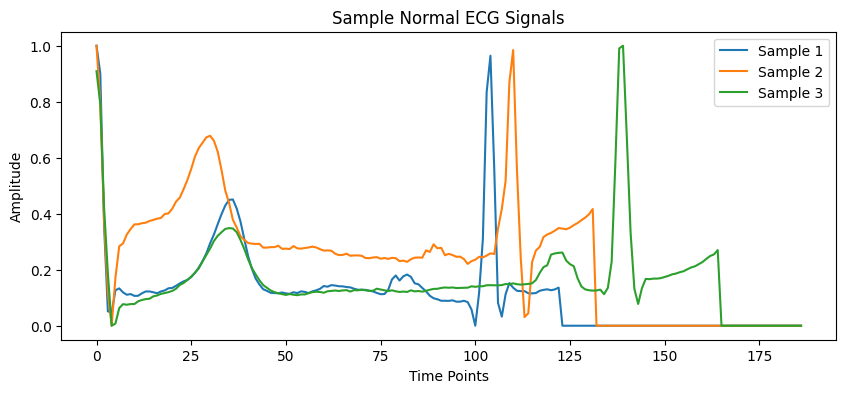

In [14]:
# 5. رسم عينة ECG
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(train_df.iloc[i, :-1], label=f'Sample {i+1}')
plt.title('Sample Normal ECG Signals')
plt.xlabel('Time Points')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [24]:
train_df = train_df.dropna()
test_df  = test_df.dropna()

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values.astype(int)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (4046, 187)
X_test:  (10506, 187)


In [25]:
X_train, X_val = train_test_split(X_train, test_size=0.1, random_state=42)

print('Train:     ', X_train.shape)
print('Validation:', X_val.shape)

Train:      (3641, 187)
Validation: (405, 187)


In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Train mean:', X_train.mean().round(4))
print('Train std: ', X_train.std().round(4))
print('Normalization done ✅')

Train mean: -0.0
Train std:  0.9973
Normalization done ✅


In [27]:
# توزيع الكلاسات
all_labels = np.concatenate((y_train, y_test))
all_labels_series = pd.Series(all_labels)

print('=== Class Distribution (Combined) ===')
print(all_labels_series.value_counts())
print(all_labels_series.value_counts(normalize=True))

=== Class Distribution (Combined) ===
1    10506
0     4046
Name: count, dtype: int64
1    0.721963
0    0.278037
Name: proportion, dtype: float64


In [28]:
input_dim = X_train.shape[1]  # 187

inputs = keras.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64,  activation='relu')(x)
x = layers.Dense(32,  activation='relu')(x)

# Bottleneck
bottleneck = layers.Dense(16, activation='relu')(x)

# Decoder
x = layers.Dense(32,  activation='relu')(bottleneck)
x = layers.Dense(64,  activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(input_dim, activation='linear')(x)

baseline_model = keras.Model(inputs, outputs, name='Baseline_Autoencoder')

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

baseline_model.summary()

Model: "Baseline_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 187)            │        24,123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,027 (273.54 KB)

 Trainable params: 70,027 (273.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_baseline = baseline_model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    verbose=1
)

print('Baseline training done ✅')

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.6207 - val_loss: 0.4701
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4053 - val_loss: 0.4053
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3492 - val_loss: 0.3429
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3000 - val_loss: 0.3002
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2674 - val_loss: 0.2726
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2484 - val_loss: 0.2490
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2316 - val_loss: 0.2300
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2102 - val_loss: 0.2131
Epoch 9/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1946 - val_loss: 0.1945
Epoch 10/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1818 - val_loss: 0.1877
Epoch 11/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1744 - val_loss: 0.1779
Epoch 12/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

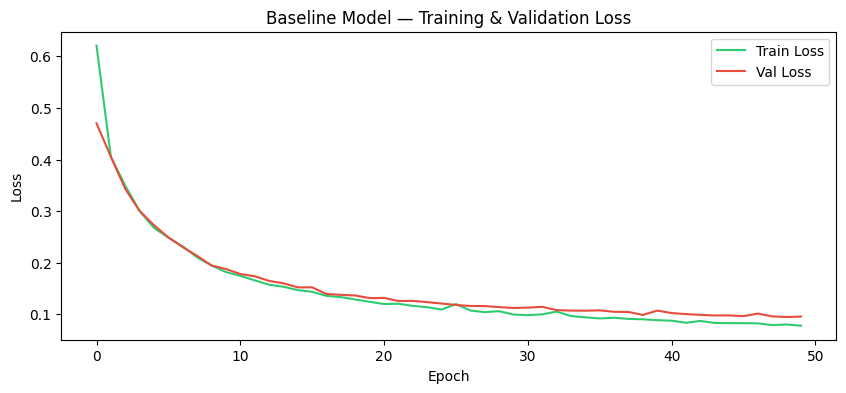

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(history_baseline.history['loss'],     label='Train Loss', color='#2ecc71')
plt.plot(history_baseline.history['val_loss'], label='Val Loss',   color='#e74c3c')

plt.title('Baseline Model — Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [31]:
# Reconstruction error
X_test_pred_base = baseline_model.predict(X_test)
errors_base = np.mean(np.power(X_test - X_test_pred_base, 2), axis=1)

# Threshold من الـ Validation
X_val_pred_base = baseline_model.predict(X_val)
val_errors_base = np.mean(np.power(X_val - X_val_pred_base, 2), axis=1)
threshold_base  = np.percentile(val_errors_base, 95)
print(f'Baseline Threshold: {threshold_base:.4f}')

# y_test كله Abnormal = 1
y_pred_base = (errors_base > threshold_base).astype(int)
y_true_base = np.ones(len(X_test), dtype=int)

print('\nBaseline Classification Report:')
print(classification_report(y_true_base, y_pred_base,
      target_names=['Normal', 'Abnormal']))

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Baseline Threshold: 0.2997

Baseline Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
    Abnormal       1.00      0.40      0.57     10506

    accuracy                           0.40     10506
   macro avg       0.50      0.20      0.28     10506
weighted avg       1.00      0.40      0.57     10506



## 📉 Training Results

The loss curve shows that both Train and Validation loss decreased
steadily from ~0.6 to ~0.09 over 50 epochs.

The two curves are close together throughout training, which indicates:
- ✅ No Overfitting — the model generalizes well
- ✅ Stable training — loss decreased smoothly
- ✅ Early Stopping was ready to activate if needed

The model successfully learned to reconstruct normal ECG signals.

In [32]:
# ادمج Normal من Validation مع Abnormal في Test
X_test_final = np.vstack([X_val, X_test])
y_true_final = np.hstack([
    np.zeros(len(X_val), dtype=int),   # Normal = 0
    np.ones(len(X_test),  dtype=int)   # Abnormal = 1
])

# Reconstruction error
X_test_final_pred = baseline_model.predict(X_test_final)
errors_final = np.mean(np.power(X_test_final - X_test_final_pred, 2), axis=1)

# Threshold
threshold_base = np.percentile(val_errors_base, 95)
print(f'Baseline Threshold: {threshold_base:.4f}')

# Predict
y_pred_base = (errors_final > threshold_base).astype(int)

print('\nBaseline Classification Report:')
print(classification_report(y_true_final, y_pred_base,
      target_names=['Normal', 'Abnormal']))

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Baseline Threshold: 0.2997

Baseline Classification Report:
              precision    recall  f1-score   support

      Normal       0.06      0.95      0.11       405
    Abnormal       0.99      0.40      0.57     10506

    accuracy                           0.42     10911
   macro avg       0.53      0.67      0.34     10911
weighted avg       0.96      0.42      0.55     10911



In [33]:
inputs = keras.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)

# Bottleneck
bottleneck = layers.Dense(16, activation='relu')(x)

# Decoder
x = layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(bottleneck)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
outputs = layers.Dense(input_dim, activation='linear')(x)

advanced_model = keras.Model(inputs, outputs, name='Advanced_Autoencoder')

advanced_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

advanced_model.summary()

Model: "Advanced_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 187)            │        24,123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,027 (273.54 KB)

 Trainable params: 70,027 (273.54 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_advanced = advanced_model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1
)

print('Advanced training done ✅')

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 1.0522 - val_loss: 0.8299
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7629 - val_loss: 0.6704
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6375 - val_loss: 0.5979
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5816 - val_loss: 0.5633
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5544 - val_loss: 0.5363
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5302 - val_loss: 0.5241
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5242 - val_loss: 0.5149
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5084 - val_loss: 0.5189
Epoch 9/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4962 - val_loss: 0.4992
Epoch 10/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4942 - val_loss: 0.4974
Epoch 11/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4907 - val_loss: 0.4854
Epoch 12/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/s

In [35]:
# Reconstruction error
X_test_pred_adv = advanced_model.predict(X_test_final)
errors_adv = np.mean(np.power(X_test_final - X_test_pred_adv, 2), axis=1)

# Threshold
X_val_pred_adv  = advanced_model.predict(X_val)
val_errors_adv  = np.mean(np.power(X_val - X_val_pred_adv, 2), axis=1)
threshold_adv   = np.percentile(val_errors_adv, 95)
print(f'Advanced Threshold: {threshold_adv:.4f}')

# Predict
y_pred_adv = (errors_adv > threshold_adv).astype(int)

print('\nAdvanced Classification Report:')
print(classification_report(y_true_final, y_pred_adv,
      target_names=['Normal', 'Abnormal']))

341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Advanced Threshold: 0.8100

Advanced Classification Report:
              precision    recall  f1-score   support

      Normal       0.06      0.95      0.10       405
    Abnormal       0.99      0.38      0.55     10506

    accuracy                           0.40     10911
   macro avg       0.53      0.66      0.33     10911
weighted avg       0.96      0.40      0.53     10911



In [36]:
def build_model(hp):
    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(hp.Choice('units', [64, 128]), activation='relu')(inputs)
    x = layers.Dropout(hp.Float('dropout', 0.1, 0.3, step=0.1))(x)
    bottleneck = layers.Dense(16, activation='relu')(x)

    # Decoder
    x = layers.Dense(hp.Choice('units', [64, 128]), activation='relu')(bottleneck)
    outputs = layers.Dense(input_dim, activation='linear')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('lr', [0.001, 0.0005])),
        loss='mse'
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory='tuner',
    project_name='ecg'
)

tuner.search(
    X_train, X_train,
    epochs=20,
    validation_data=(X_val, X_val),
    callbacks=[EarlyStopping(patience=3)],
    verbose=0
)

print('Best Hyperparameters:')
print(tuner.get_best_hyperparameters(1)[0].values)

Best Hyperparameters:
{'units': 128, 'dropout': 0.1, 'lr': 0.001}


In [37]:
# نتائج Baseline
X_pred_base = baseline_model.predict(X_test_final, verbose=0)
errors_base  = np.mean(np.power(X_test_final - X_pred_base, 2), axis=1)
threshold_base = np.percentile(errors_base[:len(X_val)], 95)
y_pred_base  = (errors_base > threshold_base).astype(int)

# نتائج Advanced
X_pred_adv  = advanced_model.predict(X_test_final, verbose=0)
errors_adv   = np.mean(np.power(X_test_final - X_pred_adv, 2), axis=1)
threshold_adv = np.percentile(errors_adv[:len(X_val)], 95)
y_pred_adv   = (errors_adv > threshold_adv).astype(int)

# المقارنة
from sklearn.metrics import f1_score, accuracy_score

print('='*45)
print(f'{"Model":<20} {"Accuracy":>10} {"F1 Score":>10}')
print('='*45)
print(f'{"Baseline":<20} {accuracy_score(y_true_final, y_pred_base):>10.2f} {f1_score(y_true_final, y_pred_base, average="weighted"):>10.2f}')
print(f'{"Advanced":<20} {accuracy_score(y_true_final, y_pred_adv):>10.2f} {f1_score(y_true_final, y_pred_adv, average="weighted"):>10.2f}')
print('='*45)

Model                  Accuracy   F1 Score
Baseline                   0.42       0.55
Advanced                   0.40       0.53


In [38]:
import joblib

# حفظ النموذج
advanced_model.save('anomaly_detection_model.h5')

# حفظ الـ Scaler والـ Threshold
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(threshold_adv, 'threshold.pkl')

print('Model saved ')
print('Scaler saved ')
print('Threshold saved ')

Model saved 
Scaler saved 
Threshold saved 
